# Bank Marketing Campaign
---
**Dataset:** UCI Bank Marketing Dataset  
**Business Problem:** A Portuguese bank ran direct phone-call marketing campaigns to sell term deposits.  
The goal of this EDA is to understand *which customer segments convert*, *when to call*, and *how prior contact history affects outcomes* — so that future campaigns can be better targeted.

**Target variable:** `y` — Did the client subscribe to a term deposit? (`yes` / `no`)

---
## Table of Contents
1. [Environment & Imports](#1)
2. [Data Loading & Schema](#2)
3. [Data Quality Audit](#3)
4. [Class Imbalance (Target Distribution)](#4)
5. [Univariate Analysis — Numerical Features](#5)
6. [Univariate Analysis — Categorical Features](#6)
7. [Bivariate Analysis — Feature vs Target](#7)
8. [Multivariate Analysis](#8)
9. [Campaign & Contact History](#9)
10. [Key Findings Summary](#10)


## 1. Environment & Imports <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import f_oneway, chi2_contingency, probplot
import warnings
warnings.filterwarnings('ignore')
ArithmeticError

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Visual theme ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (10, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

## 2. Data Loading & Schema <a id='2'></a>

In [2]:
# Load the full dataset (45,211 rows)
df = pd.read_csv("../data/bank-full.csv", sep=';')

print("Shape:", df.shape)
df.head()


Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
# Column data types at a glance
print(df.dtypes)
print("\nNumerical columns :", list(df.select_dtypes(include='number').columns))
print("Categorical columns:", list(df.select_dtypes(include='object').columns))


age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

Numerical columns : ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


## 3. Data Quality Audit <a id='3'></a>
We check for: nulls, 'unknown' placeholders, impossible values, and encoding quirks.


In [4]:
# checking for null values in the dataset
df.isnull().sum()

# No null values found

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [5]:
# ── 3b. 'unknown' placeholders in categorical columns ────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()

unknown_report = []
for col in cat_cols:
    n = (df[col] == 'unknown').sum()
    pct = n / len(df) * 100
    if n > 0:
        unknown_report.append({'column': col, 'unknown_count': n, 'unknown_pct': round(pct, 2)})

unknown_df = pd.DataFrame(unknown_report).sort_values('unknown_pct', ascending=False)
print("Columns with 'unknown' values:")
print(unknown_df.to_string(index=False))
print("\nDecision: Retain 'unknown' as a valid category for now; flag in modelling.")


Columns with 'unknown' values:
   column  unknown_count  unknown_pct
 poutcome          36959        81.75
  contact          13020        28.80
education           1857         4.11
      job            288         0.64

Decision: Retain 'unknown' as a valid category for now; flag in modelling.


In [6]:
# ── 3c. pdays special encoding: -1 means 'never previously contacted' ─────────
# This is NOT a real numeric value — it is a sentinel.
pdays_neg = (df['pdays'] == -1).sum()
print(f"pdays = -1 (never contacted): {pdays_neg:,} rows  ({pdays_neg/len(df)*100:.1f}%)")
print(f"pdays > 0  (was contacted)  : {(df['pdays'] > 0).sum():,} rows")

# Create a cleaner binary flag and a filtered series for real values
df['was_previously_contacted'] = (df['pdays'] != -1).astype(int)
pdays_real = df.loc[df['pdays'] != -1, 'pdays']
print(f"\npdays stats (excluding -1 sentinel):")
print(pdays_real.describe().round(1))


pdays = -1 (never contacted): 36,954 rows  (81.7%)
pdays > 0  (was contacted)  : 8,257 rows

pdays stats (excluding -1 sentinel):
count    8257.0
mean      224.6
std       115.3
min         1.0
25%       133.0
50%       194.0
75%       327.0
max       871.0
Name: pdays, dtype: float64


In [7]:
# ── 3d. Validate numerical ranges ────────────────────────────────────────────
num_cols = df.select_dtypes(include='number').columns.tolist()
print(df[num_cols].describe().T[['min','max','mean','50%']].round(2))


                             min       max     mean    50%
age                         18.0      95.0    40.94   39.0
balance                  -8019.0  102127.0  1362.27  448.0
day                          1.0      31.0    15.81   16.0
duration                     0.0    4918.0   258.16  180.0
campaign                     1.0      63.0     2.76    2.0
pdays                       -1.0     871.0    40.20   -1.0
previous                     0.0     275.0     0.58    0.0
was_previously_contacted     0.0       1.0     0.18    0.0


## 4. Class Imbalance — Target Distribution <a id='4'></a>
> **This is the most important cell in the notebook.**  
> Every acceptance rate computed below must be interpreted relative to the **baseline conversion rate**.


In [8]:
target_counts = df['y'].value_counts()
target_pct    = df['y'].value_counts(normalize=True) * 100

BASELINE_CONVERSION = target_pct['yes']

print("=== Target Distribution ===")
for label in ['yes', 'no']:
    print(f"  {label:>3}  {target_counts[label]:>6,}  ({target_pct[label]:.1f}%)")
print(f"\nBaseline conversion rate: {BASELINE_CONVERSION:.2f}%")
print("Class imbalance ratio (No:Yes):", round(target_counts['no'] / target_counts['yes'], 1), ":1")
print("\n⚠️  Implication for modelling: accuracy is a misleading metric here.")
print("   Use AUC-ROC, F1 (for 'yes' class), or Precision-Recall AUC.")


=== Target Distribution ===
  yes   5,289  (11.7%)
   no  39,922  (88.3%)

Baseline conversion rate: 11.70%
Class imbalance ratio (No:Yes): 7.5 :1

⚠️  Implication for modelling: accuracy is a misleading metric here.
   Use AUC-ROC, F1 (for 'yes' class), or Precision-Recall AUC.


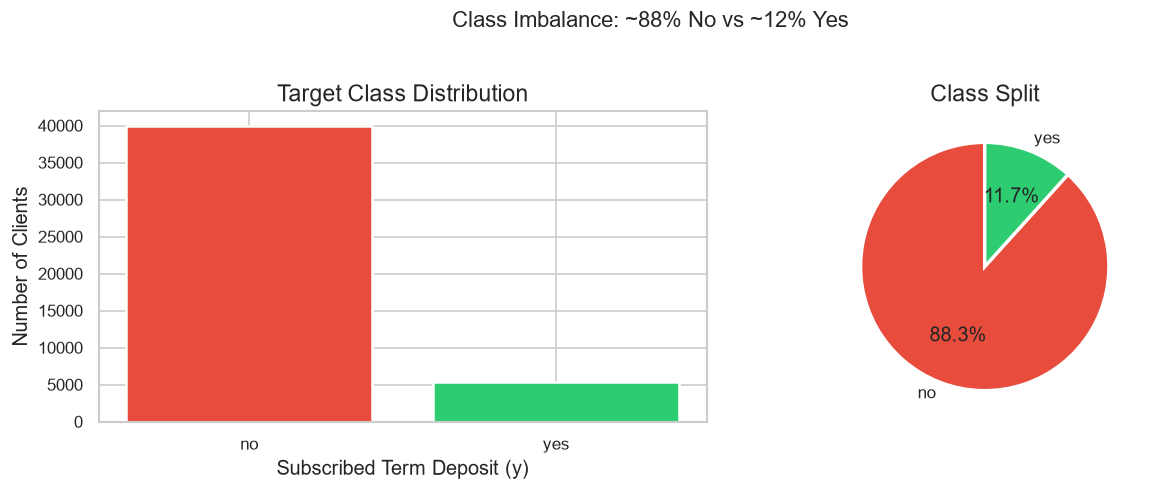

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Number of Clients')
axes[0].set_xlabel('Subscribed Term Deposit (y)')

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Split')

plt.suptitle('Class Imbalance: ~88% No vs ~12% Yes', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 5. Univariate Analysis — Numerical Features <a id='5'></a>

### 5.1 Age

In [10]:
print(df['age'].describe().round(2))
print(f"Skewness : {df['age'].skew():.3f}")
print(f"Kurtosis : {df['age'].kurtosis():.3f}")

Q1, Q3 = df['age'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df['age'] < lower) | (df['age'] > upper)]
print(f"IQR fence: [{lower:.0f}, {upper:.0f}]  |  Outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)")


count    45211.00
mean        40.94
std         10.62
min         18.00
25%         33.00
50%         39.00
75%         48.00
max         95.00
Name: age, dtype: float64
Skewness : 0.685
Kurtosis : 0.320
IQR fence: [10, 70]  |  Outliers: 487 (1.1%)


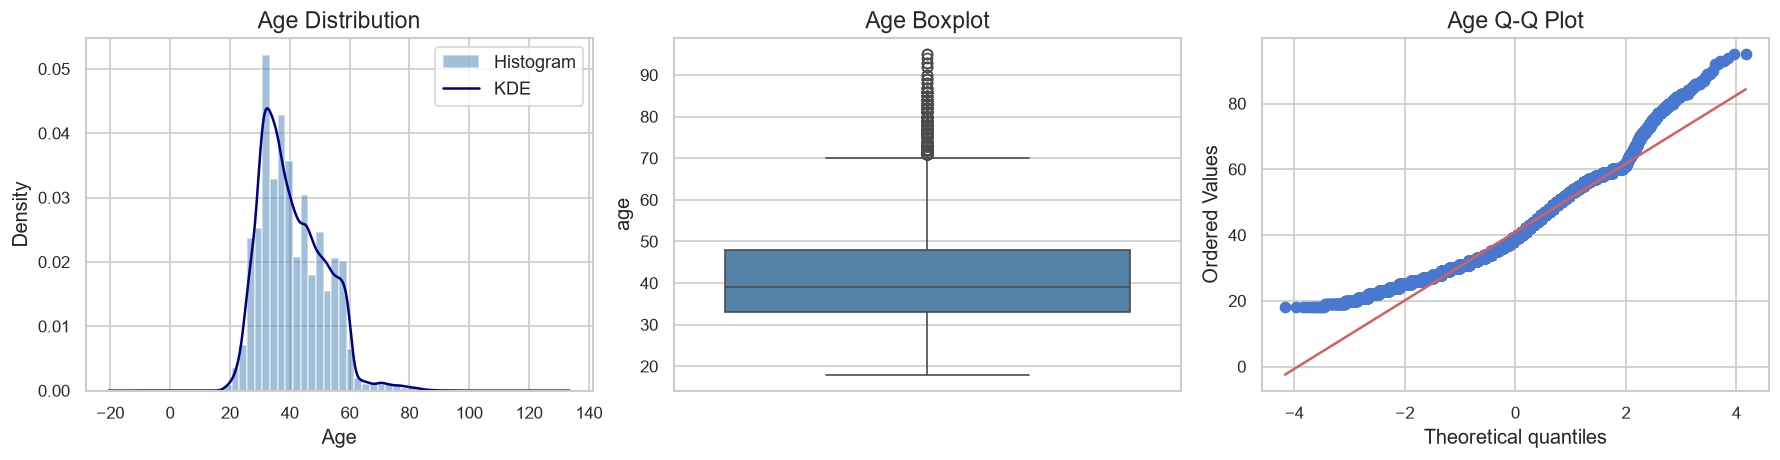

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram + KDE
df['age'].plot(kind='hist', bins=30, density=True, alpha=0.5, ax=axes[0], label='Histogram', color='steelblue')
df['age'].plot(kind='kde', ax=axes[0], label='KDE', color='navy')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].legend()

# Boxplot
sns.boxplot(y=df['age'], ax=axes[1], color='steelblue')
axes[1].set_title('Age Boxplot')

# Q-Q plot
probplot(df['age'], plot=axes[2])
axes[2].set_title('Age Q-Q Plot')

plt.tight_layout()
plt.show()


### 5.2 Balance

In [12]:
print(df['balance'].describe().round(2))
print(f"Skewness : {df['balance'].skew():.3f}  (highly skewed — consider log transform for modelling)")
negative_bal = (df['balance'] < 0).sum()
print(f"Negative balances: {negative_bal:,} ({negative_bal/len(df)*100:.1f}%) — clients in overdraft, valid.")


count     45211.00
mean       1362.27
std        3044.77
min       -8019.00
25%          72.00
50%         448.00
75%        1428.00
max      102127.00
Name: balance, dtype: float64
Skewness : 8.360  (highly skewed — consider log transform for modelling)
Negative balances: 3,766 (8.3%) — clients in overdraft, valid.


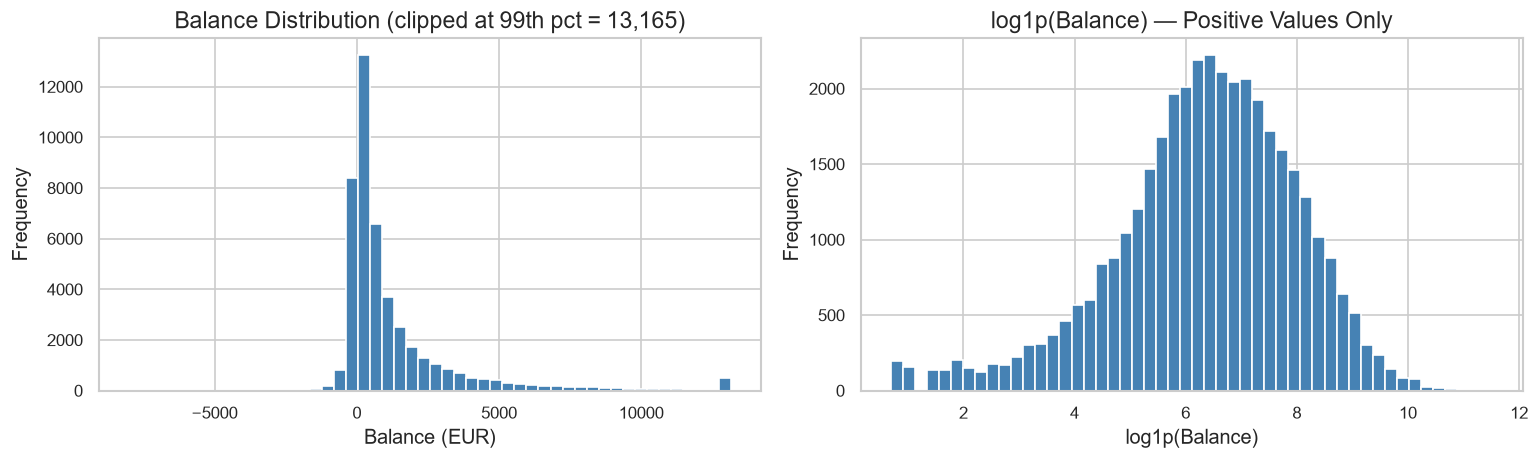

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Clipped for visibility
clip_val = df['balance'].quantile(0.99)
df['balance'].clip(upper=clip_val).plot(
    kind='hist', bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title(f'Balance Distribution (clipped at 99th pct = {clip_val:,.0f})')
axes[0].set_xlabel('Balance (EUR)')

# Log-transformed (positive only)
bal_pos = df.loc[df['balance'] > 0, 'balance']
np.log1p(bal_pos).plot(kind='hist', bins=50, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('log1p(Balance) — Positive Values Only')
axes[1].set_xlabel('log1p(Balance)')

plt.tight_layout()
plt.show()

### 5.3 Duration

In [14]:
print(df['duration'].describe().round(2))

count    45211.00
mean       258.16
std        257.53
min          0.00
25%        103.00
50%        180.00
75%        319.00
max       4918.00
Name: duration, dtype: float64


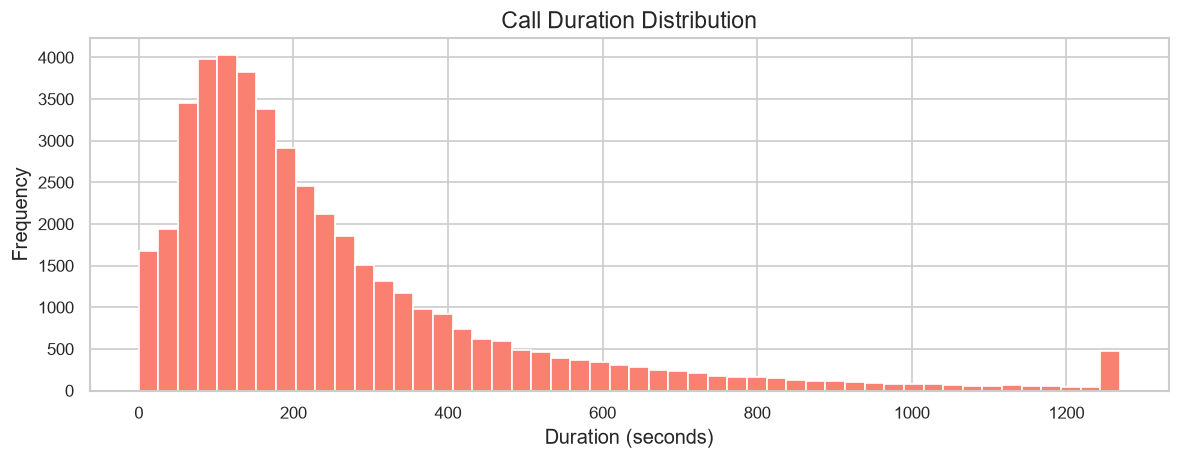

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
df['duration'].clip(upper=df['duration'].quantile(0.99)).plot(
    kind='hist', bins=50, ax=ax, color='salmon', edgecolor='white')
ax.set_title('Call Duration Distribution')
ax.set_xlabel('Duration (seconds)')
plt.tight_layout()
plt.show()


> ⚠️ **Data Leakage Warning — `duration`**  
> Call duration is only known *after* the call ends. It cannot be used as a predictor in a real deployment because you don't know how long a call will be *before* dialling.  
> The UCI dataset documentation explicitly states: *"this attribute highly affects the output target. Yet, if the goal is to have a realistic predictive model, this attribute should be discarded."*  
> **Action: Exclude `duration` from any feature set used for modelling.**


### 5.4 Campaign Contacts

In [16]:
print(df['campaign'].describe().round(2))
print(f"\nClients contacted >5 times: {(df['campaign']>5).sum():,} ({(df['campaign']>5).mean()*100:.1f}%)")

count    45211.00
mean         2.76
std          3.10
min          1.00
25%          1.00
50%          2.00
75%          3.00
max         63.00
Name: campaign, dtype: float64

Clients contacted >5 times: 4,355 (9.6%)


## 6. Univariate Analysis — Categorical Features <a id='6'></a>

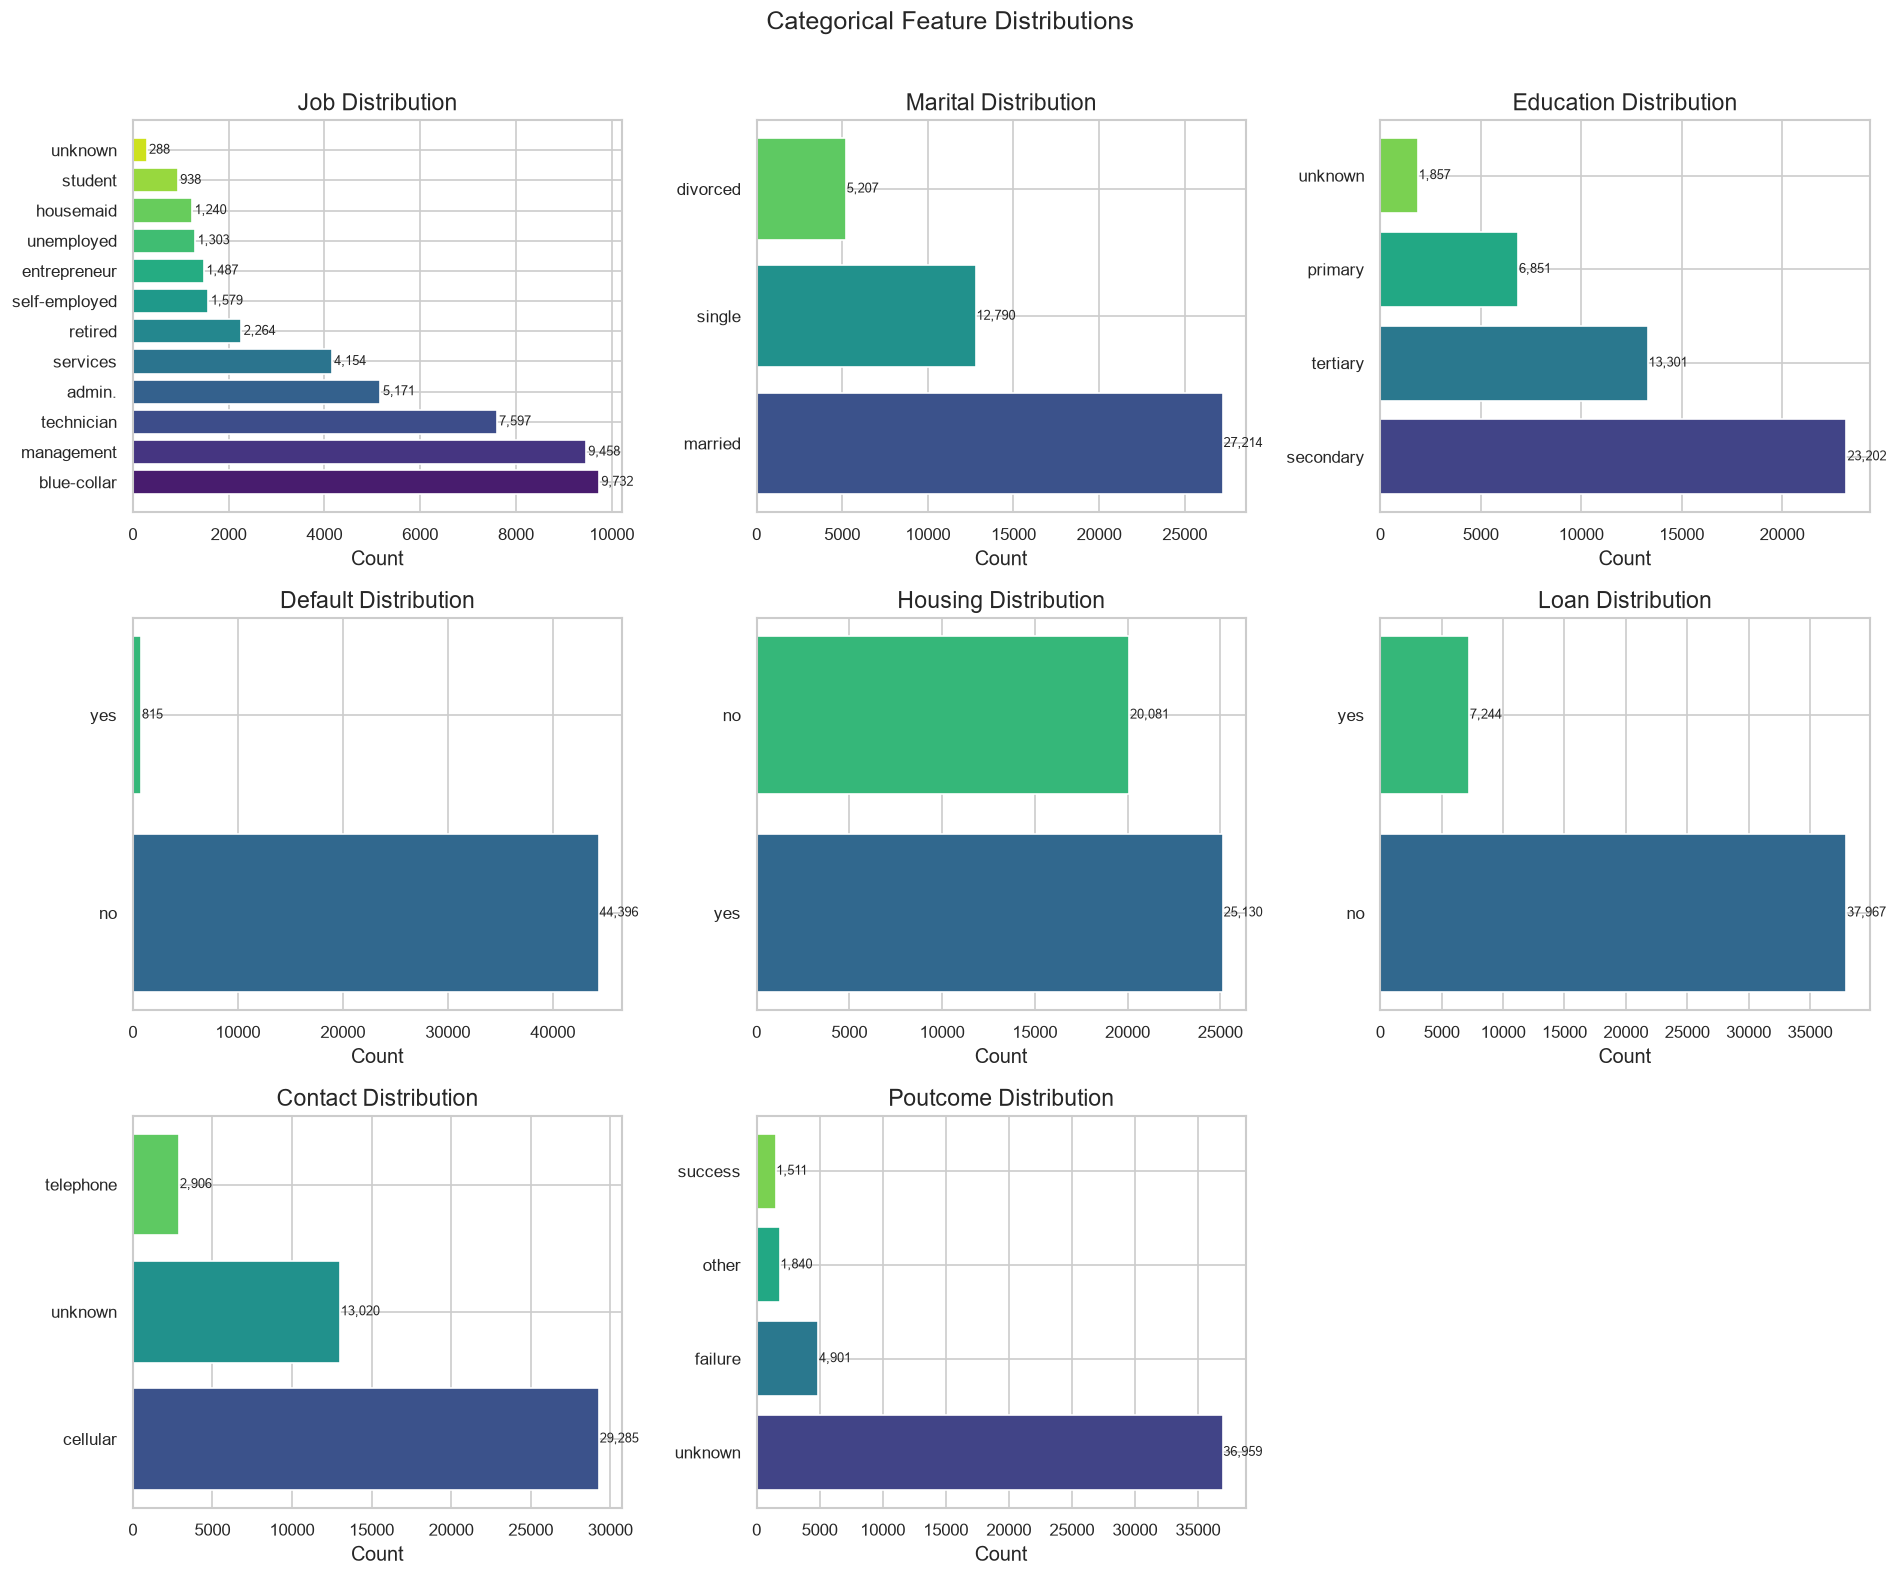

In [17]:
cat_cols_display = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(cat_cols_display):
    vc = df[col].value_counts()
    axes[i].barh(vc.index, vc.values, color=sns.color_palette('viridis', len(vc)))
    axes[i].set_title(f'{col.capitalize()} Distribution')
    axes[i].set_xlabel('Count')
    for j, v in enumerate(vc.values):
        axes[i].text(v + 50, j, f'{v:,}', va='center', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Categorical Feature Distributions', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


## 7. Bivariate Analysis — Feature vs Target <a id='7'></a>
Each acceptance rate is shown alongside the **baseline (dashed line)** so we can immediately see which segments over/under-perform.


### 7.1 Age vs Target

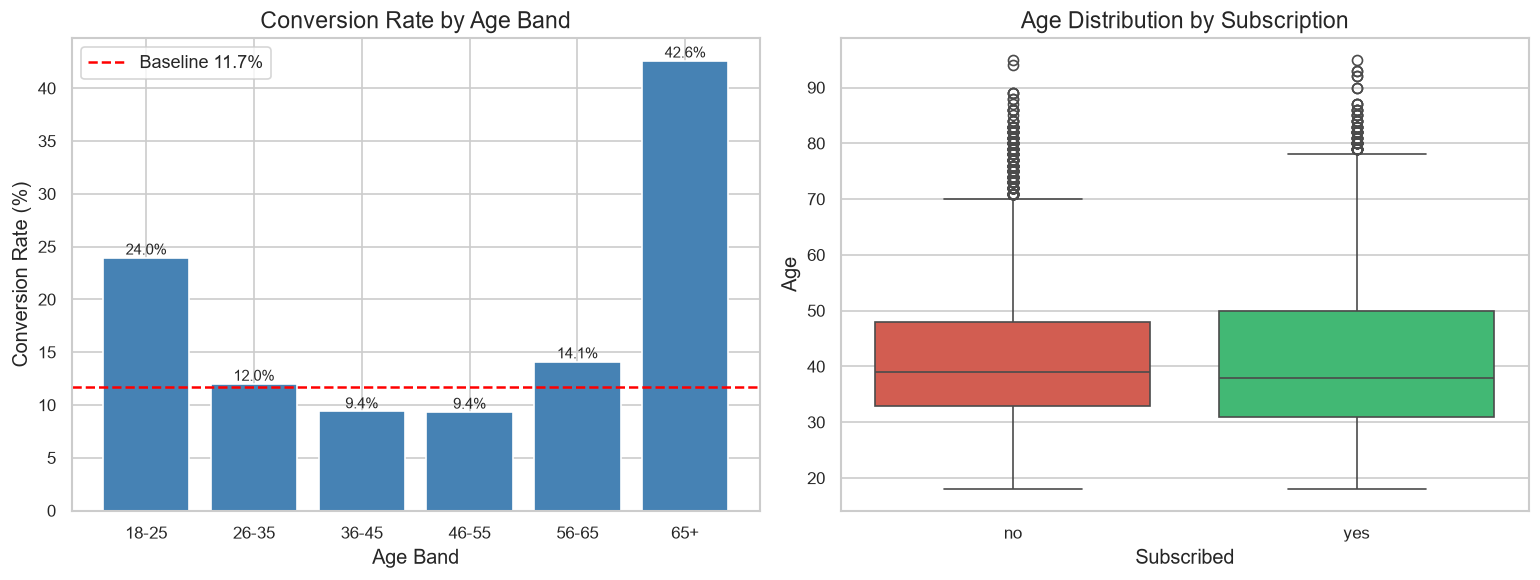

One-way ANOVA — Age vs y:  F=28.63,  p=8.83e-08
Insight: Seniors (65+) have significantly higher conversion rates.


In [18]:
# Age bins for cleaner business interpretation
df['age_band'] = pd.cut(df['age'], bins=[17,25,35,45,55,65,100],
                         labels=['18-25','26-35','36-45','46-55','56-65','65+'])

age_acc = (
    df.groupby('age_band', observed=True)
    .agg(total=('y','count'), converted=('y', lambda x: (x=='yes').sum()))
    .assign(conv_rate=lambda x: x['converted']/x['total']*100)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(age_acc['age_band'].astype(str), age_acc['conv_rate'], color='steelblue', edgecolor='white')
axes[0].axhline(BASELINE_CONVERSION, color='red', linestyle='--', linewidth=1.5, label=f'Baseline {BASELINE_CONVERSION:.1f}%')
axes[0].set_title('Conversion Rate by Age Band')
axes[0].set_xlabel('Age Band')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].legend()
for i, row in age_acc.iterrows():
    axes[0].text(i, row['conv_rate']+0.3, f"{row['conv_rate']:.1f}%", ha='center', fontsize=9)

sns.boxplot(x='y', y='age', data=df, palette={'yes':'#2ecc71','no':'#e74c3c'}, ax=axes[1])
axes[1].set_title('Age Distribution by Subscription')
axes[1].set_xlabel('Subscribed')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

# Statistical test
groups = [df[df['y']==label]['age'] for label in ['yes','no']]
f_stat, p_val = f_oneway(*groups)
print(f"One-way ANOVA — Age vs y:  F={f_stat:.2f},  p={p_val:.2e}")
print("Insight: Seniors (65+) have significantly higher conversion rates.")


### 7.2 Job vs Target

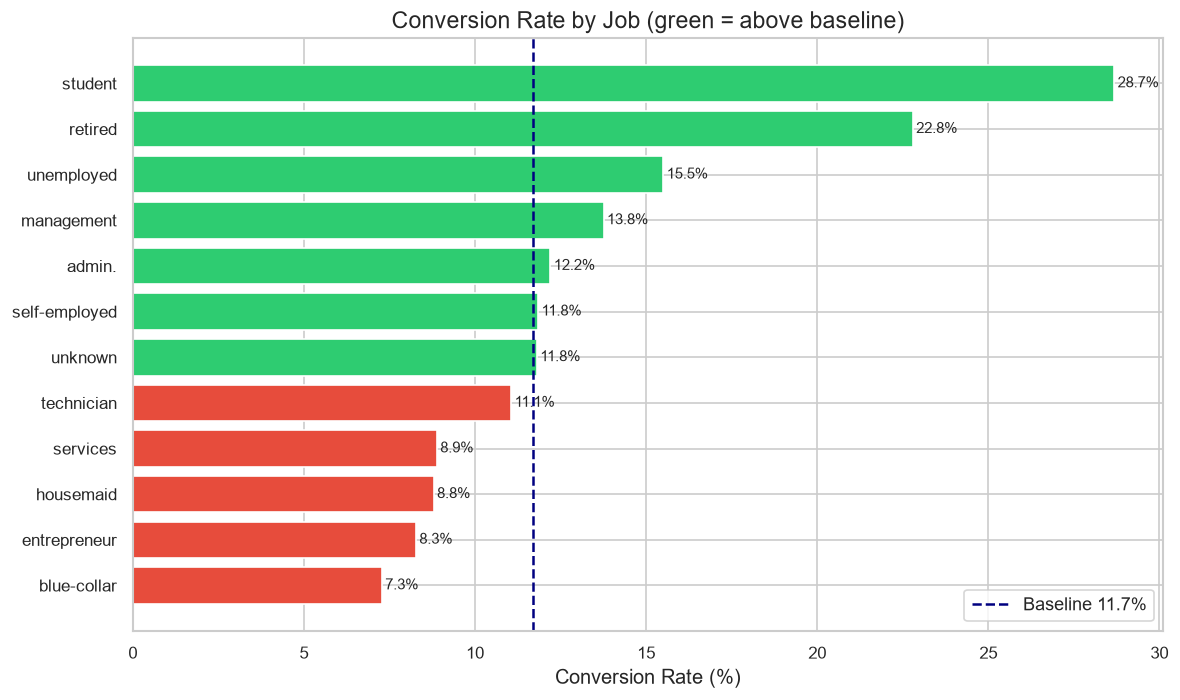

In [19]:
job_acc = (
    df.groupby('job')
    .agg(total=('y','count'), converted=('y', lambda x: (x=='yes').sum()))
    .assign(conv_rate=lambda x: x['converted']/x['total']*100)
    .sort_values('conv_rate', ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(job_acc['job'], job_acc['conv_rate'],
               color=['#2ecc71' if v > BASELINE_CONVERSION else '#e74c3c' for v in job_acc['conv_rate']])
ax.axvline(BASELINE_CONVERSION, color='navy', linestyle='--', linewidth=1.5, label=f'Baseline {BASELINE_CONVERSION:.1f}%')
ax.set_title('Conversion Rate by Job (green = above baseline)')
ax.set_xlabel('Conversion Rate (%)')
ax.legend()
for i, row in job_acc.iterrows():
    ax.text(row['conv_rate']+0.1, i, f"{row['conv_rate']:.1f}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()


### 7.3 Education vs Target

In [20]:
edu_acc = (
    df.groupby('education')
    .agg(total=('y','count'), converted=('y', lambda x: (x=='yes').sum()))
    .assign(conv_rate=lambda x: x['converted']/x['total']*100)
    .sort_values('conv_rate', ascending=False)
    .reset_index()
)
print(edu_acc.to_string(index=False))

# Chi-square test
ct = pd.crosstab(df['education'], df['y'])
chi2, p, dof, _ = chi2_contingency(ct)
print(f"\nChi-square test: chi2={chi2:.2f}, p={p:.2e}, dof={dof}")


education  total  converted  conv_rate
 tertiary  13301       1996  15.006390
  unknown   1857        252  13.570275
secondary  23202       2450  10.559435
  primary   6851        591   8.626478

Chi-square test: chi2=238.92, p=1.63e-51, dof=3


### 7.4 Marital Status vs Target

ANOVA Age ~ Marital:  F=5228.73,  p=0.00e+00


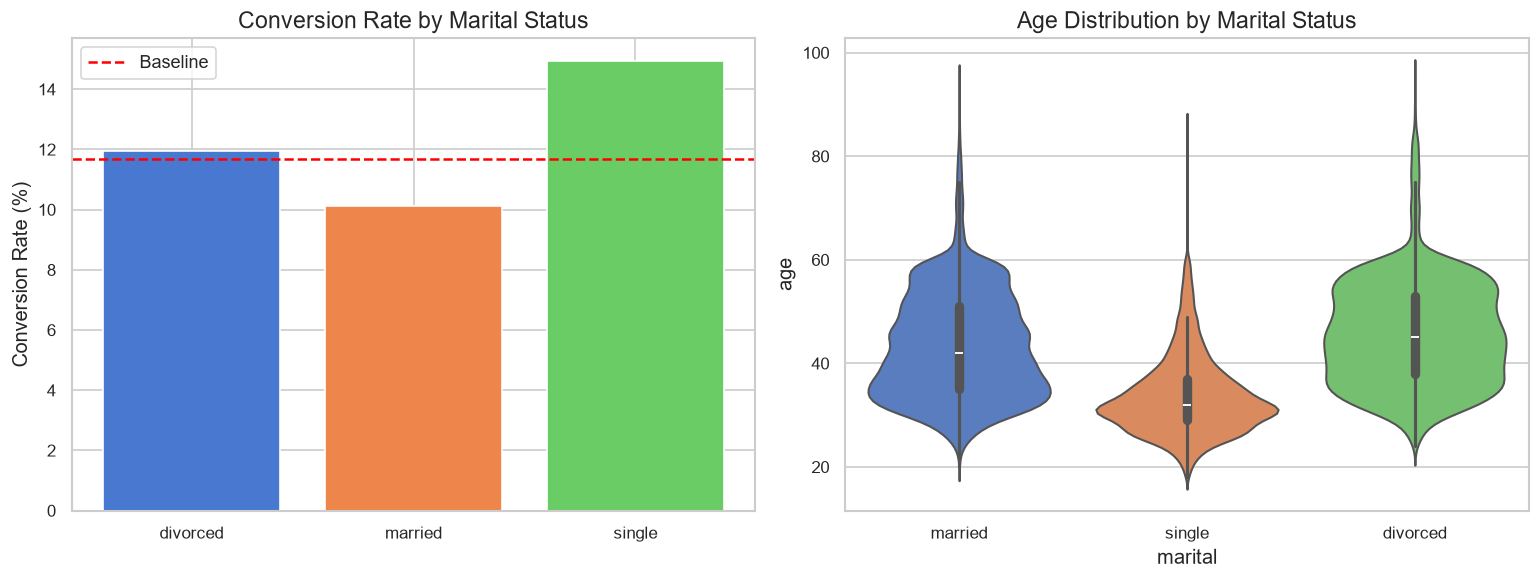

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Conversion rate
mar_acc = (
    df.groupby('marital')
    .agg(total=('y','count'), converted=('y', lambda x: (x=='yes').sum()))
    .assign(conv_rate=lambda x: x['converted']/x['total']*100)
    .reset_index()
)
axes[0].bar(mar_acc['marital'], mar_acc['conv_rate'], color=sns.color_palette('muted',3), edgecolor='white')
axes[0].axhline(BASELINE_CONVERSION, color='red', linestyle='--', label=f'Baseline')
axes[0].set_title('Conversion Rate by Marital Status')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].legend()

# Age distribution per marital status
sns.violinplot(x='marital', y='age', data=df, palette='muted', ax=axes[1])
axes[1].set_title('Age Distribution by Marital Status')

groups = [grp['age'] for _, grp in df.groupby('marital')]
f_stat, p_val = f_oneway(*groups)
print(f"ANOVA Age ~ Marital:  F={f_stat:.2f},  p={p_val:.2e}")
plt.tight_layout()
plt.show()


### 7.5 Balance vs Target

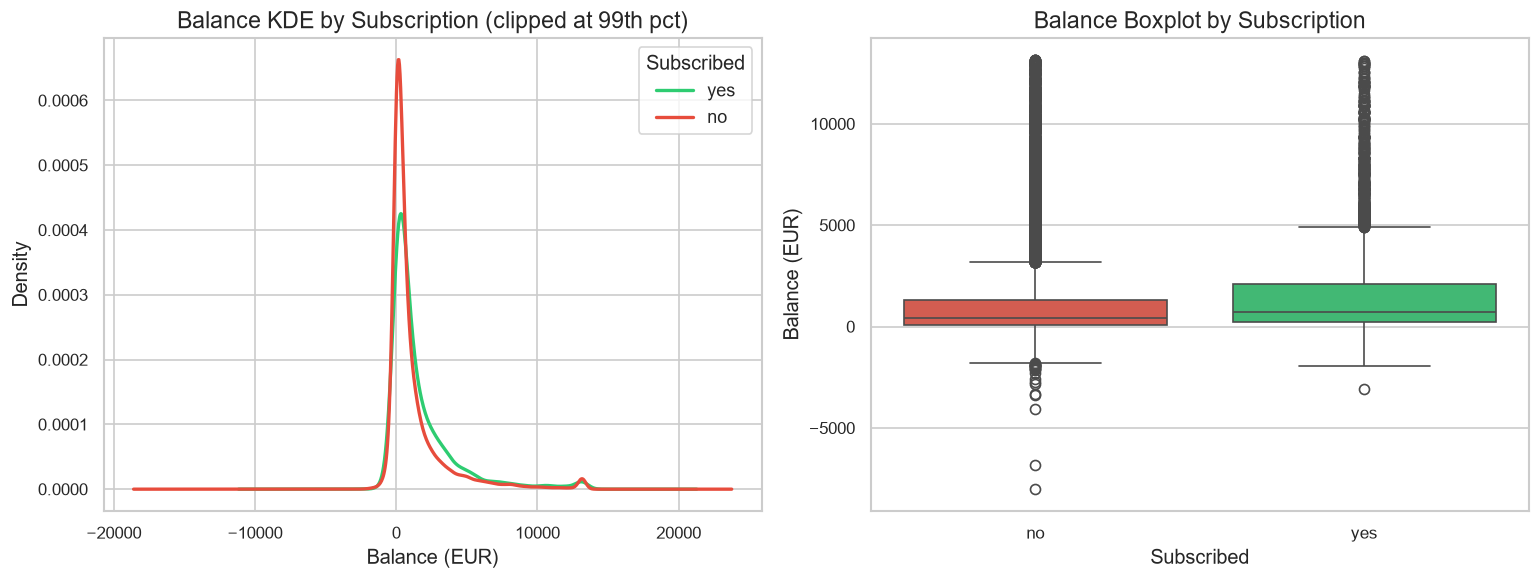

        mean  median
y                   
no   1303.71   417.0
yes  1804.27   733.0


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

clip_val = df['balance'].quantile(0.99)
for label, color in zip(['yes','no'], ['#2ecc71','#e74c3c']):
    subset = df[df['y']==label]['balance'].clip(upper=clip_val)
    subset.plot(kind='kde', ax=axes[0], label=label, color=color, linewidth=2)
axes[0].set_title('Balance KDE by Subscription (clipped at 99th pct)')
axes[0].set_xlabel('Balance (EUR)')
axes[0].legend(title='Subscribed')

sns.boxplot(x='y', y='balance', data=df[df['balance'] < clip_val],
            palette={'yes':'#2ecc71','no':'#e74c3c'}, ax=axes[1])
axes[1].set_title('Balance Boxplot by Subscription')
axes[1].set_xlabel('Subscribed')
axes[1].set_ylabel('Balance (EUR)')

plt.tight_layout()
plt.show()

print(df.groupby('y')['balance'].agg(['mean','median']).round(2))


### 7.6 Housing & Personal Loan vs Target

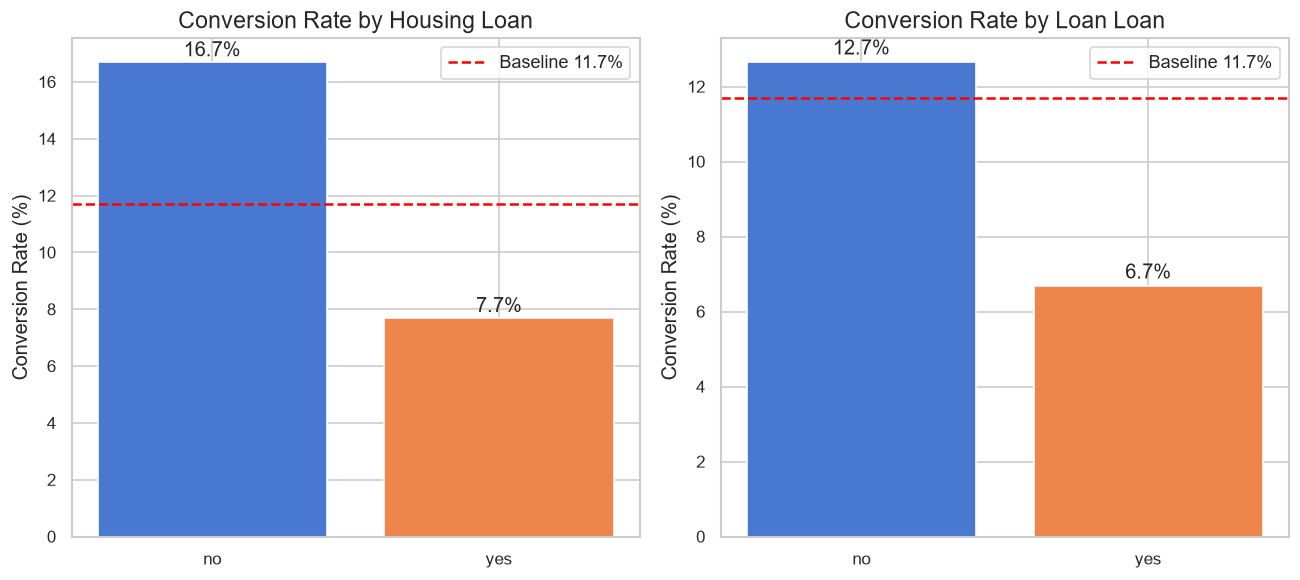

Insight: Clients with housing loans have lower conversion; personal loans show similar pattern.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, col in zip(axes, ['housing', 'loan']):
    acc = (
        df.groupby(col)
        .agg(total=('y','count'), converted=('y', lambda x: (x=='yes').sum()))
        .assign(conv_rate=lambda x: x['converted']/x['total']*100)
        .reset_index()
    )
    ax.bar(acc[col], acc['conv_rate'], color=sns.color_palette('muted',2), edgecolor='white')
    ax.axhline(BASELINE_CONVERSION, color='red', linestyle='--', label=f'Baseline {BASELINE_CONVERSION:.1f}%')
    ax.set_title(f'Conversion Rate by {col.capitalize()} Loan')
    ax.set_ylabel('Conversion Rate (%)')
    ax.legend()
    for i, row in acc.iterrows():
        ax.text(i, row['conv_rate']+0.2, f"{row['conv_rate']:.1f}%", ha='center')

plt.tight_layout()
plt.show()
print("Insight: Clients with housing loans have lower conversion; personal loans show similar pattern.")


### 7.7 Contact Type vs Target

  contact  total  converted  conv_rate
 cellular  29285       4369  14.918900
telephone   2906        390  13.420509
  unknown  13020        530   4.070661


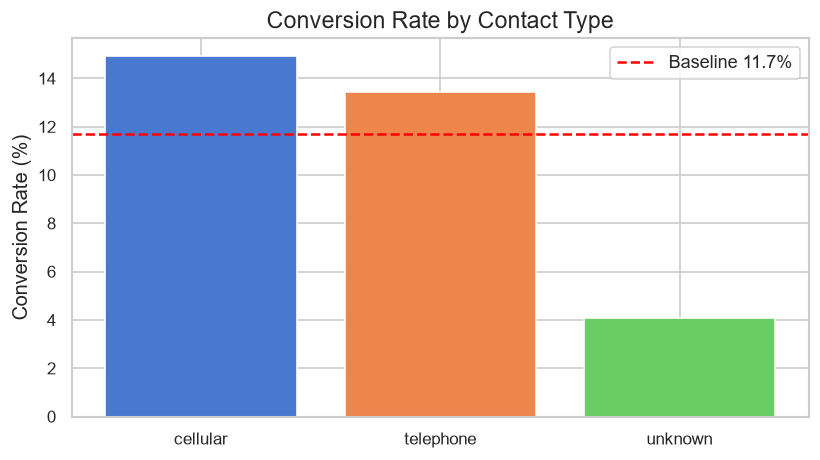

In [24]:
cont_acc = (
    df.groupby('contact')
    .agg(total=('y','count'), converted=('y', lambda x: (x=='yes').sum()))
    .assign(conv_rate=lambda x: x['converted']/x['total']*100)
    .reset_index()
)
print(cont_acc.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(cont_acc['contact'], cont_acc['conv_rate'], color=sns.color_palette('muted',3), edgecolor='white')
ax.axhline(BASELINE_CONVERSION, color='red', linestyle='--', label=f'Baseline {BASELINE_CONVERSION:.1f}%')
ax.set_title('Conversion Rate by Contact Type')
ax.set_ylabel('Conversion Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()


### 7.8 Month vs Target

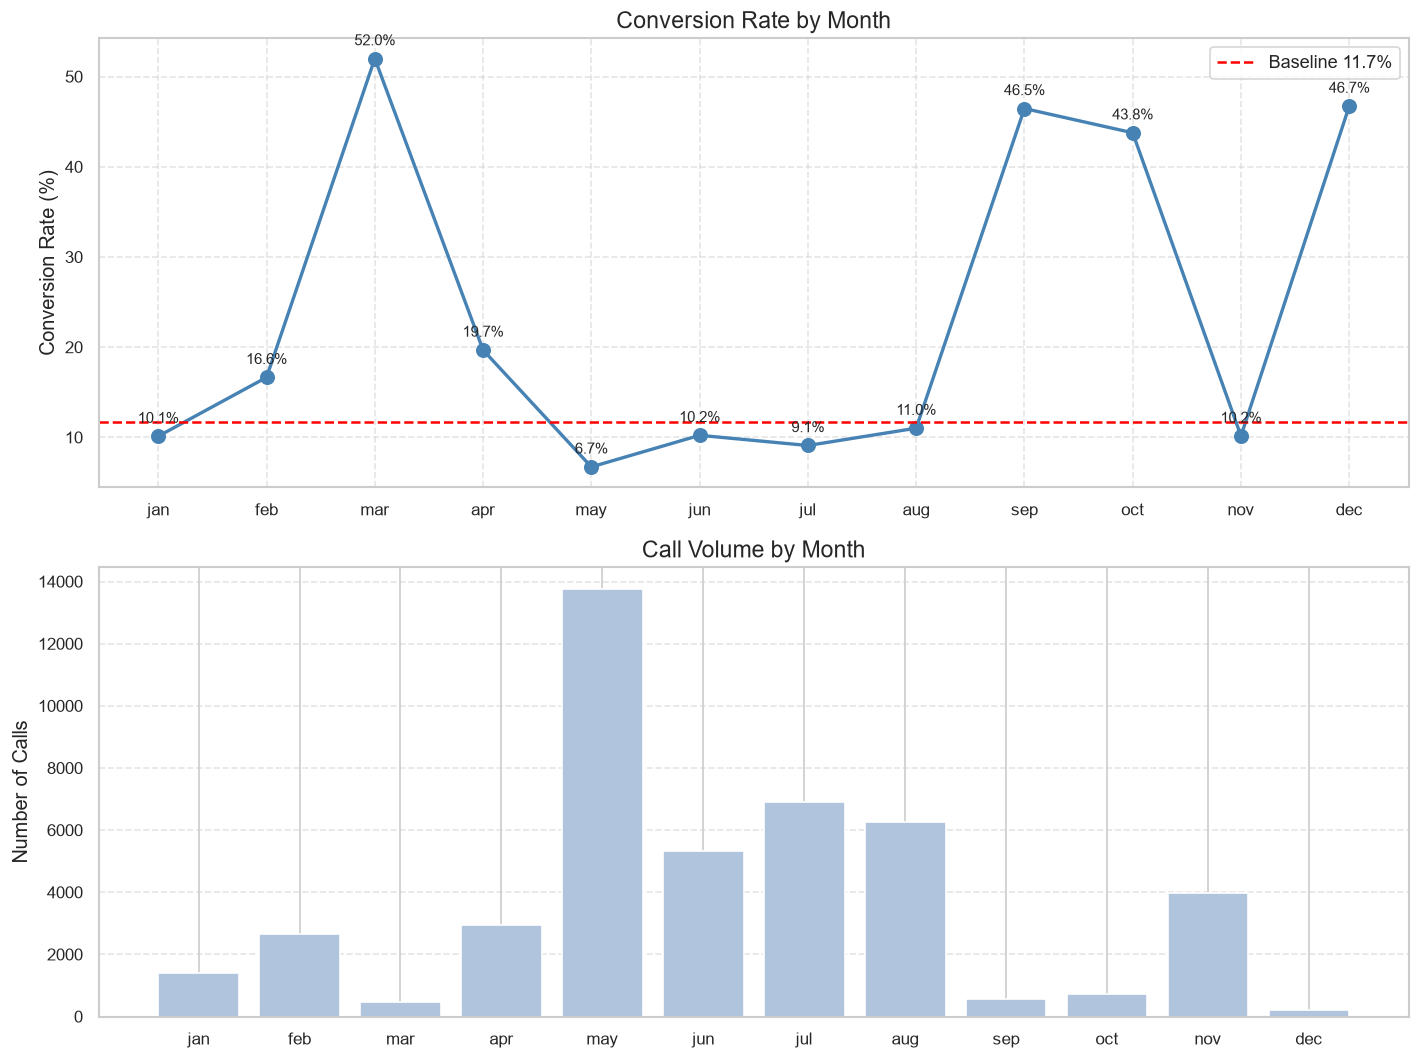

Insight: March, September, October & December show the highest conversion rates.
May has the most calls but a below-average conversion rate — potential over-campaigning.


In [25]:
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

monthly_acc = (
    df.groupby('month')
    .agg(total=('y','count'), converted=('y', lambda x: (x=='yes').sum()))
    .assign(conv_rate=lambda x: x['converted']/x['total']*100)
    .reset_index()
)
monthly_acc['month'] = pd.Categorical(monthly_acc['month'], categories=month_order, ordered=True)
monthly_acc = monthly_acc.sort_values('month').reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# Conversion rate line
axes[0].plot(monthly_acc['month'].astype(str), monthly_acc['conv_rate'],
             marker='o', color='steelblue', linewidth=2, markersize=8)
axes[0].axhline(BASELINE_CONVERSION, color='red', linestyle='--', label=f'Baseline {BASELINE_CONVERSION:.1f}%')
for _, row in monthly_acc.iterrows():
    axes[0].annotate(f"{row['conv_rate']:.1f}%",
                     xy=(row.name, row['conv_rate']),
                     xytext=(0, 8), textcoords='offset points', ha='center', fontsize=9)
axes[0].set_title('Conversion Rate by Month')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Volume bar
axes[1].bar(monthly_acc['month'].astype(str), monthly_acc['total'],
            color='lightsteelblue', edgecolor='white')
axes[1].set_title('Call Volume by Month')
axes[1].set_ylabel('Number of Calls')
axes[1].grid(True, linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.show()
print("Insight: March, September, October & December show the highest conversion rates.")
print("May has the most calls but a below-average conversion rate — potential over-campaigning.")


### 7.9 Previous Campaign Outcome (poutcome) vs Target

poutcome  total  converted  conv_rate
 success   1511        978  64.725347
   other   1840        307  16.684783
 failure   4901        618  12.609671
 unknown  36959       3386   9.161503


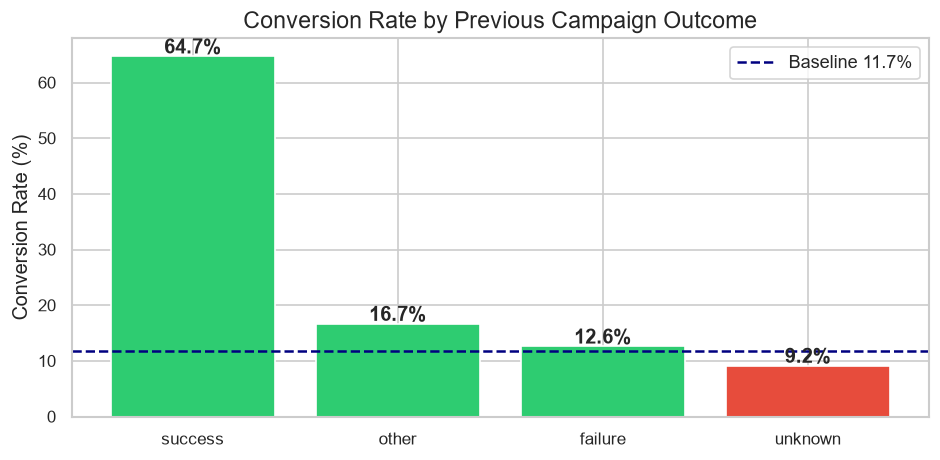


⭐ Most powerful predictor: poutcome='success' converts at ~65% vs 11% baseline.


In [26]:
pout_acc = (
    df.groupby('poutcome')
    .agg(total=('y','count'), converted=('y', lambda x: (x=='yes').sum()))
    .assign(conv_rate=lambda x: x['converted']/x['total']*100)
    .sort_values('conv_rate', ascending=False)
    .reset_index()
)
print(pout_acc.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71' if v > BASELINE_CONVERSION else '#e74c3c' for v in pout_acc['conv_rate']]
ax.bar(pout_acc['poutcome'], pout_acc['conv_rate'], color=colors, edgecolor='white')
ax.axhline(BASELINE_CONVERSION, color='navy', linestyle='--', label=f'Baseline {BASELINE_CONVERSION:.1f}%')
ax.set_title('Conversion Rate by Previous Campaign Outcome')
ax.set_ylabel('Conversion Rate (%)')
ax.legend()
for i, row in pout_acc.iterrows():
    ax.text(i, row['conv_rate']+0.5, f"{row['conv_rate']:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print("\n⭐ Most powerful predictor: poutcome='success' converts at ~65% vs 11% baseline.")


## 8. Multivariate Analysis <a id='8'></a>

### 8.1 Correlation Heatmap — Numerical Features

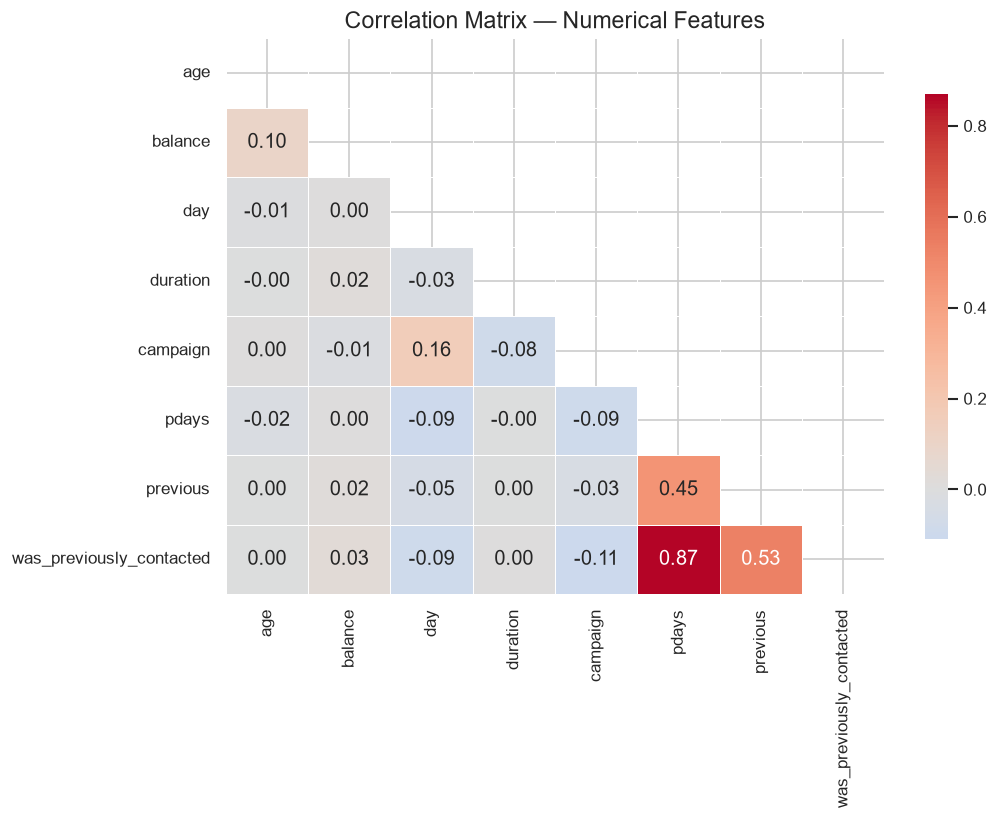

Note: duration is strongly correlated with target but is a leakage variable.


In [27]:
num_cols = df.select_dtypes(include='number').columns.tolist()
# Exclude was_previously_contacted (engineered) for pure correlation view
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()
print("Note: duration is strongly correlated with target but is a leakage variable.")


### 8.2 Golden Segments — Job × Education

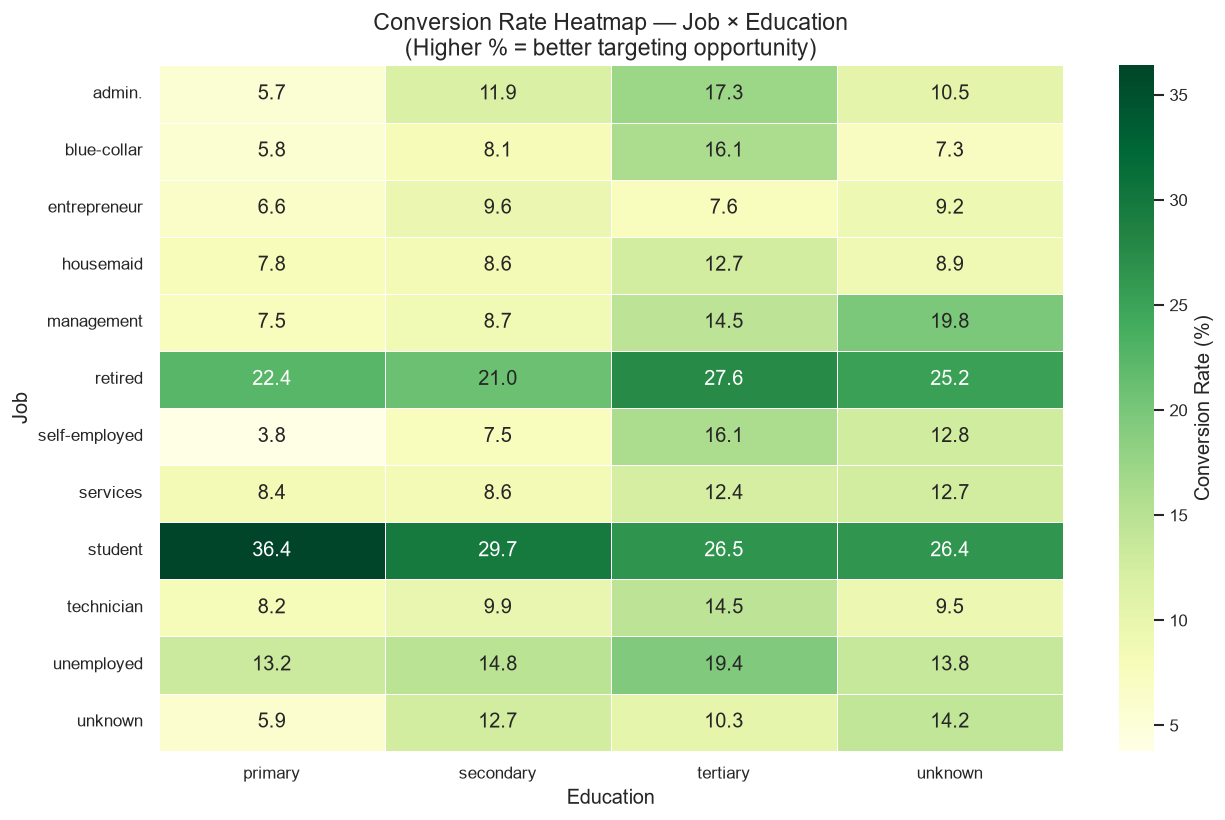

In [28]:
seg = (
    df.groupby(['job','education'])
    .agg(total=('y','count'), converted=('y', lambda x: (x=='yes').sum()))
    .assign(conv_rate=lambda x: x['converted']/x['total']*100)
    .reset_index()
)

# Pivot for heatmap
pivot = seg.pivot(index='job', columns='education', values='conv_rate').round(1)

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGn', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Conversion Rate (%)'})
ax.set_title('Conversion Rate Heatmap — Job × Education\n(Higher % = better targeting opportunity)')
ax.set_xlabel('Education')
ax.set_ylabel('Job')
plt.tight_layout()
plt.show()


### 8.3 Balance vs Age, coloured by Target

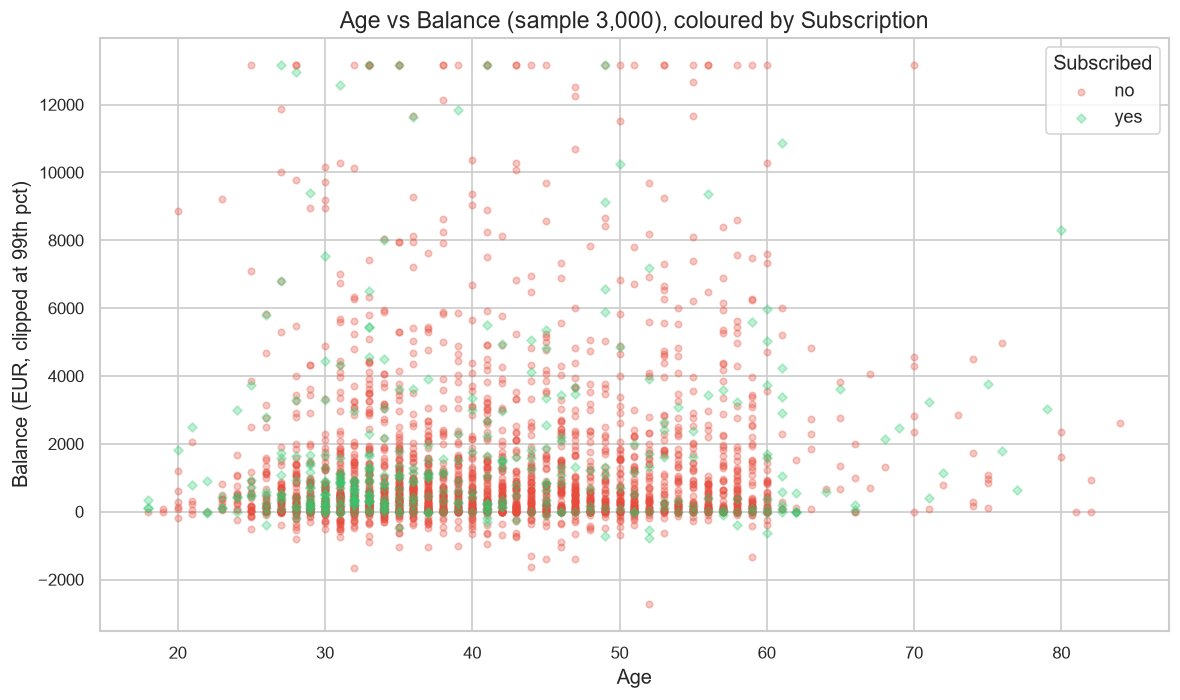

In [29]:
sample = df.sample(3000, random_state=RANDOM_SEED)
clip_bal = df['balance'].quantile(0.99)

fig, ax = plt.subplots(figsize=(10, 6))
for label, color, marker in zip(['no','yes'],['#e74c3c','#2ecc71'],['o','D']):
    sub = sample[sample['y']==label]
    ax.scatter(sub['age'], sub['balance'].clip(upper=clip_bal),
               alpha=0.3, s=15, label=label, color=color, marker=marker)
ax.set_title('Age vs Balance (sample 3,000), coloured by Subscription')
ax.set_xlabel('Age')
ax.set_ylabel('Balance (EUR, clipped at 99th pct)')
ax.legend(title='Subscribed')
plt.tight_layout()
plt.show()


## 9. Campaign & Contact History <a id='9'></a>

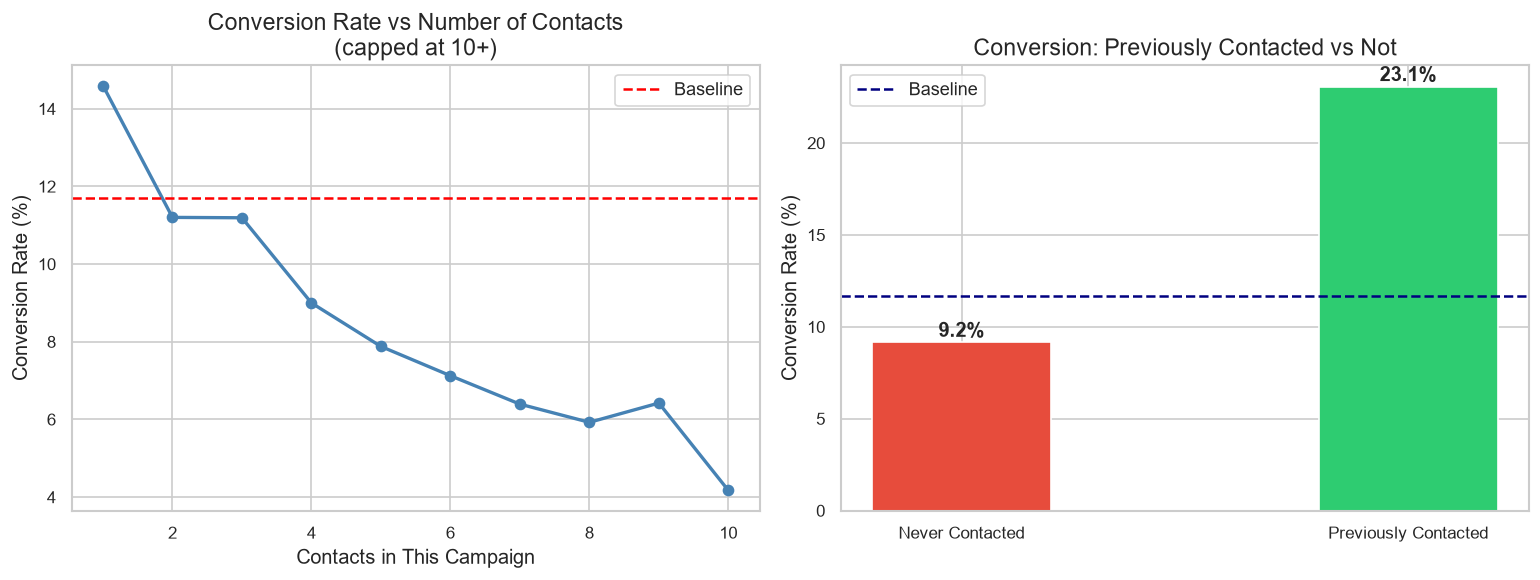

Insight: Conversion drops sharply after 3 contacts — diminishing returns from repeated calls.


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Campaign contacts vs conversion
camp_acc = (
    df.assign(campaign_capped=df['campaign'].clip(upper=10))
    .groupby('campaign_capped')
    .agg(total=('y','count'), converted=('y', lambda x: (x=='yes').sum()))
    .assign(conv_rate=lambda x: x['converted']/x['total']*100)
    .reset_index()
)
axes[0].plot(camp_acc['campaign_capped'], camp_acc['conv_rate'],
             marker='o', color='steelblue', linewidth=2)
axes[0].axhline(BASELINE_CONVERSION, color='red', linestyle='--', label='Baseline')
axes[0].set_title('Conversion Rate vs Number of Contacts\n(capped at 10+)')
axes[0].set_xlabel('Contacts in This Campaign')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].legend()

# Previously contacted vs not
prev_acc = (
    df.groupby('was_previously_contacted')
    .agg(total=('y','count'), converted=('y', lambda x: (x=='yes').sum()))
    .assign(conv_rate=lambda x: x['converted']/x['total']*100)
    .reset_index()
)
prev_acc['label'] = prev_acc['was_previously_contacted'].map({0:'Never Contacted',1:'Previously Contacted'})
axes[1].bar(prev_acc['label'], prev_acc['conv_rate'],
            color=['#e74c3c','#2ecc71'], edgecolor='white', width=0.4)
axes[1].axhline(BASELINE_CONVERSION, color='navy', linestyle='--', label='Baseline')
axes[1].set_title('Conversion: Previously Contacted vs Not')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].legend()
for i, row in prev_acc.iterrows():
    axes[1].text(i, row['conv_rate']+0.3, f"{row['conv_rate']:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("Insight: Conversion drops sharply after 3 contacts — diminishing returns from repeated calls.")


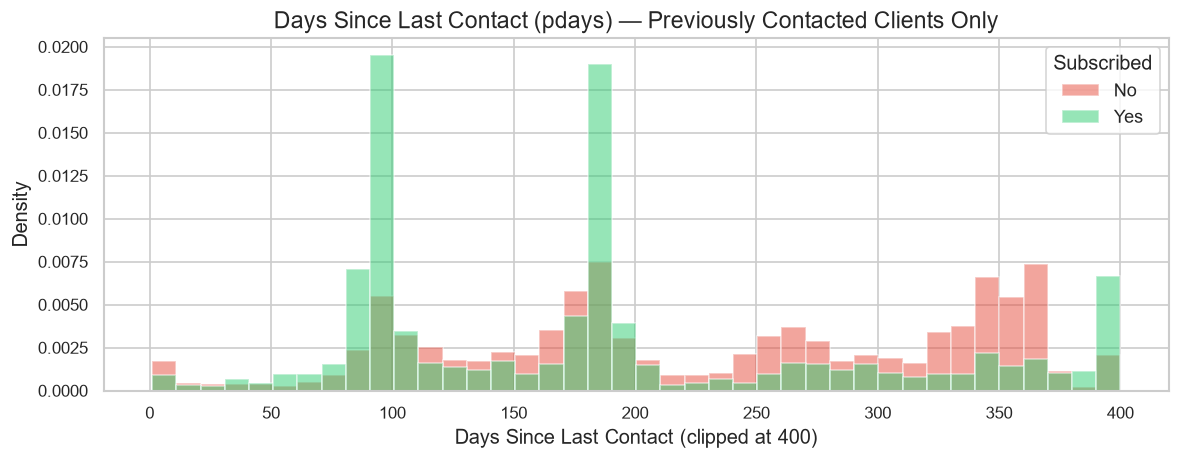

In [31]:
# Days since last contact (pdays) — only for previously contacted clients
fig, ax = plt.subplots(figsize=(10, 4))
pdays_real_yes = df[(df['pdays'] != -1) & (df['y']=='yes')]['pdays']
pdays_real_no  = df[(df['pdays'] != -1) & (df['y']=='no')]['pdays']

ax.hist(pdays_real_no.clip(upper=400),  bins=40, alpha=0.5, color='#e74c3c', label='No',  density=True)
ax.hist(pdays_real_yes.clip(upper=400), bins=40, alpha=0.5, color='#2ecc71', label='Yes', density=True)
ax.set_title('Days Since Last Contact (pdays) — Previously Contacted Clients Only')
ax.set_xlabel('Days Since Last Contact (clipped at 400)')
ax.set_ylabel('Density')
ax.legend(title='Subscribed')
plt.tight_layout()
plt.show()


## 10. Key Findings Summary <a id='10'></a>

| # | Feature | Finding | Business Action |
|---|---------|---------|-----------------|
| 1 | **Class Imbalance** | ~88% No, ~12% Yes. Severe imbalance. | Use AUC-ROC / F1 for modelling; consider SMOTE or class weights. |
| 2 | **poutcome = success** | ~65% conversion vs 11% baseline — 6× lift | Prioritise clients with previous successful campaign contact. |
| 3 | **Age 65+** | Highest conversion rate among age bands | Include in premium targeting segment. |
| 4 | **Job: student, retired** | Both above baseline | Target younger students and retirees. |
| 5 | **Month: Mar, Sep, Oct, Dec** | Peak conversion months | Schedule intensive campaigns in these months. |
| 6 | **Month: May** | Highest volume, below-average conversion | Reduce May call volume; reallocate to Sep/Oct. |
| 7 | **Campaign contacts > 3** | Conversion drops sharply after 3 calls | Set a 3-contact cap per client per campaign. |
| 8 | **Housing loan = yes** | Below baseline conversion | Deprioritise this segment or adjust product messaging. |
| 9 | **Contact: cellular** | Higher conversion than telephone | Prefer mobile contact where available. |
| 10 | **`duration`** | Strong correlation with `y` but **leakage** | **Must exclude from any model feature set.** |

---
### What to Do Next
1. **Feature Engineering:** Encode `poutcome`, `was_previously_contacted`, `age_band` as model features; apply `log1p` to `balance`.
2. **Modelling:** Use Logistic Regression (baseline), then Gradient Boosting (LightGBM / XGBoost) with class weights.
3. **Evaluation Metric:** Precision-Recall AUC or F1 on the minority class (`yes`), not accuracy.
4. **Business KPI:** Expected conversion lift over random dialling = primary success metric for deployment.
